In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bloodmoon.mask import codedmask, decode
from bloodmoon.coords import angle2shift
from bloodmoon.optim import model_shadowgram

from darksun.show import DSPlot


# setup mask and instr effects
basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
# basepath = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'

UPX, UPY = 5, 1
wfm = codedmask(maskpath, UPX, UPY)
VIGNETTING = True
PSFY = False

ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)

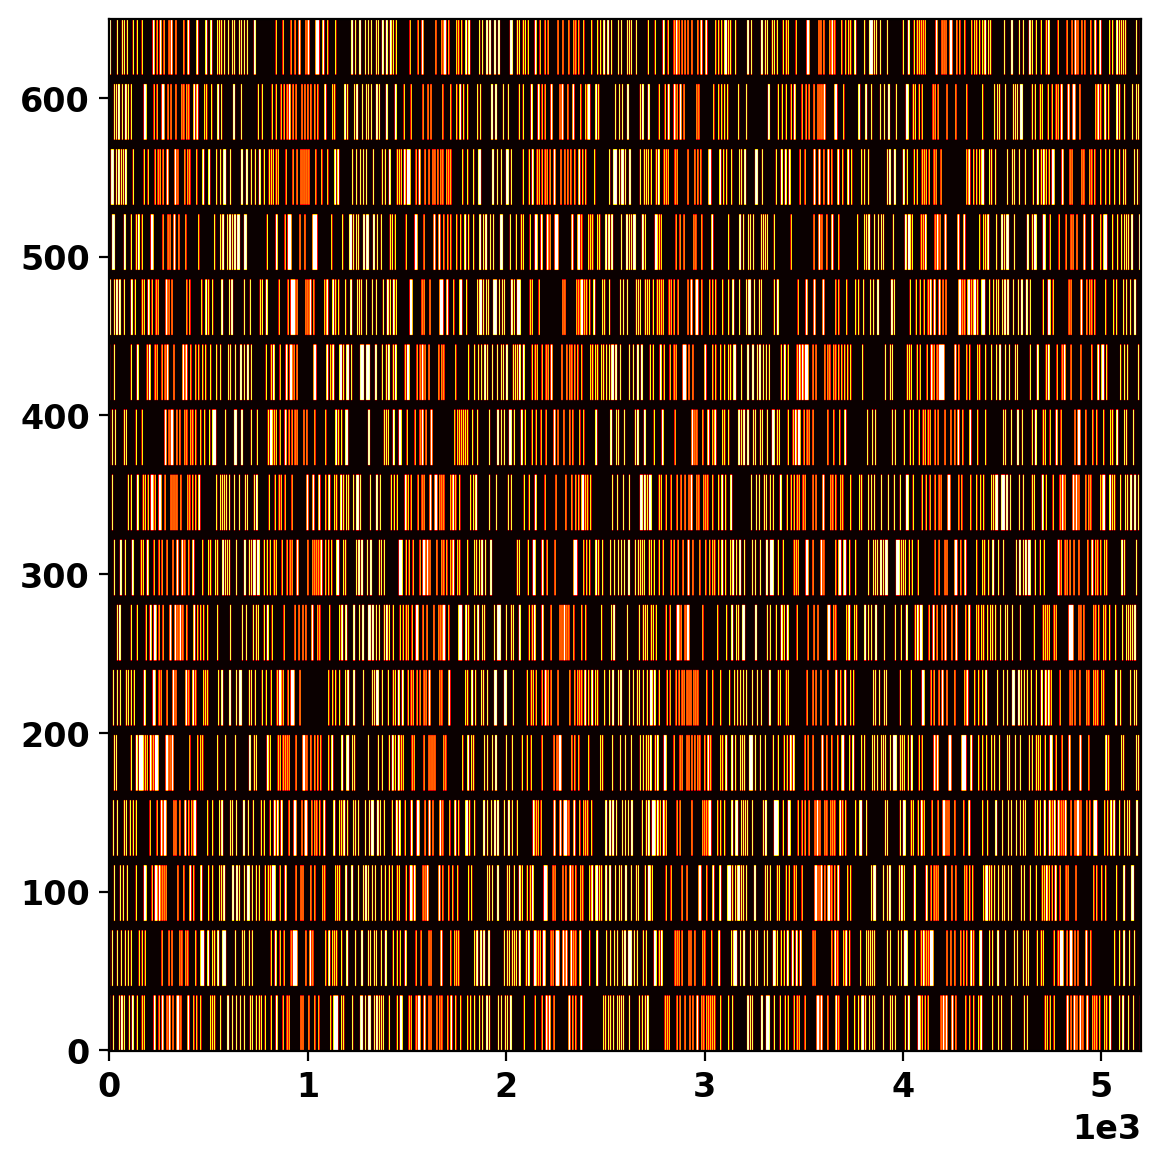

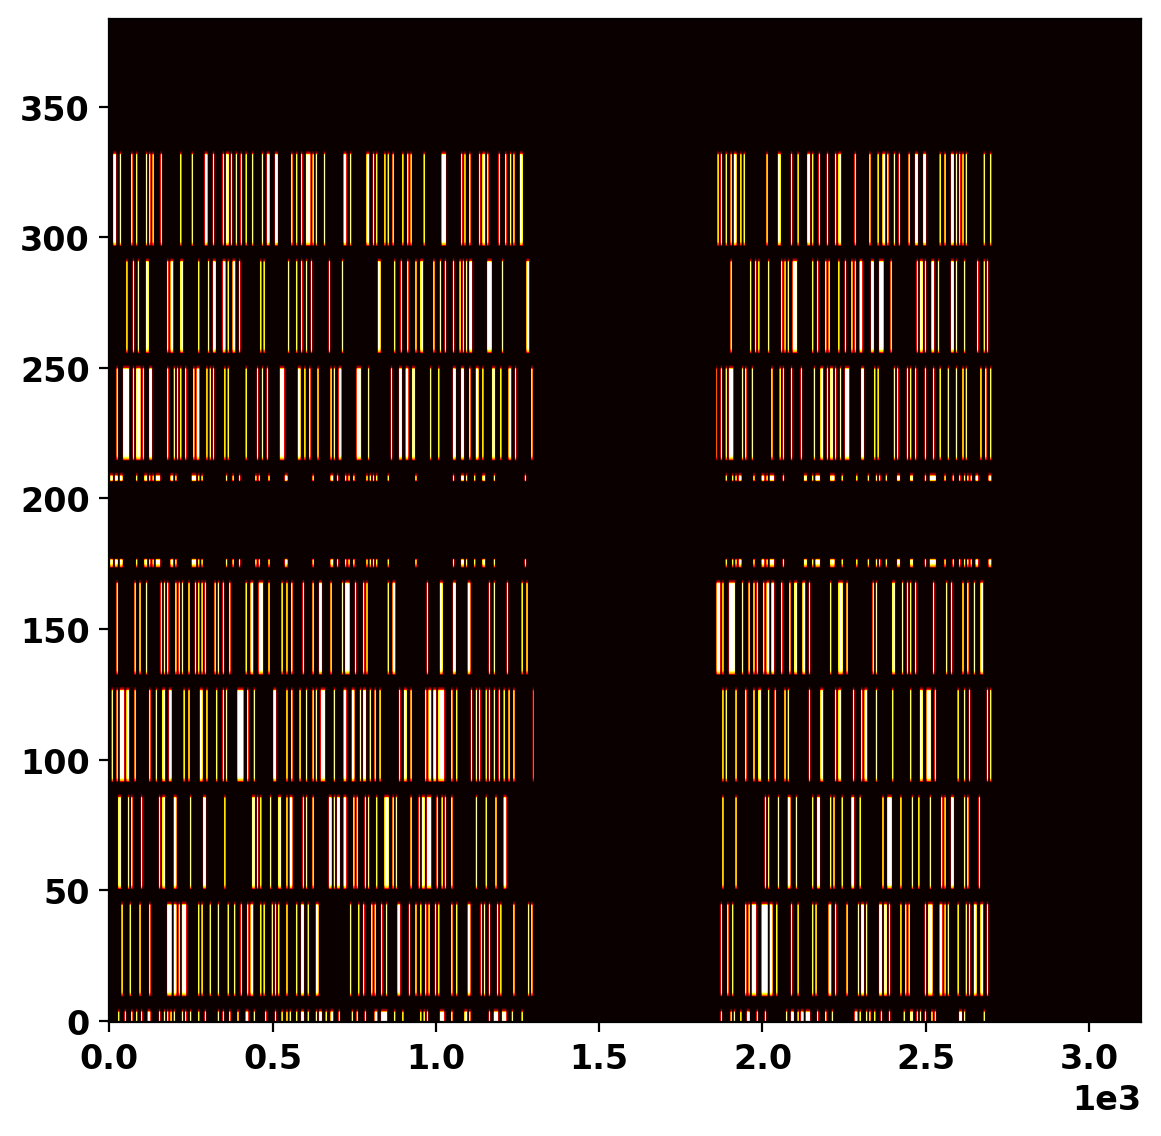

In [2]:
save_to = '/mnt/d/PhD_AASS/Workshops/AASS Workshop 2025'
dsp = DSPlot(1, 1)

# camera mask
fig, ax = dsp.config_subplots(ptype='image')
ax.imshow(wfm.mask, cmap='hot', origin='lower', aspect=ASPECT)
#fig.savefig(f'{save_to}/wfm_mask.png')
plt.show()


# detector image
shifty, shiftx = (
    angle2shift(wfm, 20.0),
    angle2shift(wfm, 20.0),
)
detector = model_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY)

fig, ax = dsp.config_subplots(ptype='image')
ax.imshow(detector, cmap='hot', origin='lower', aspect=ASPECT)
#fig.savefig(f'{save_to}/detector_image.png')
plt.show()

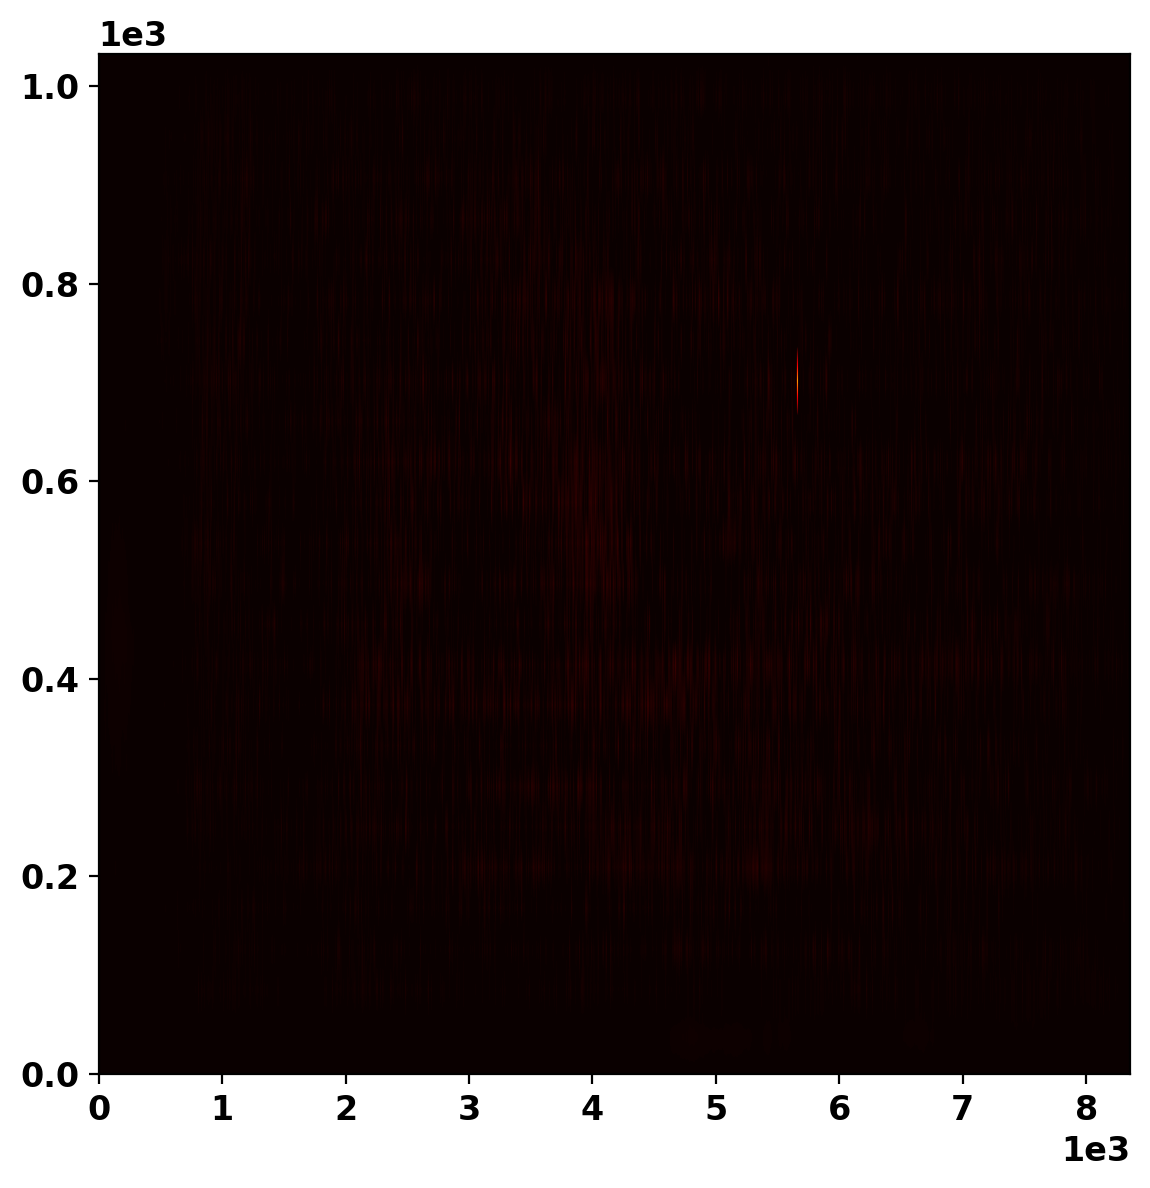

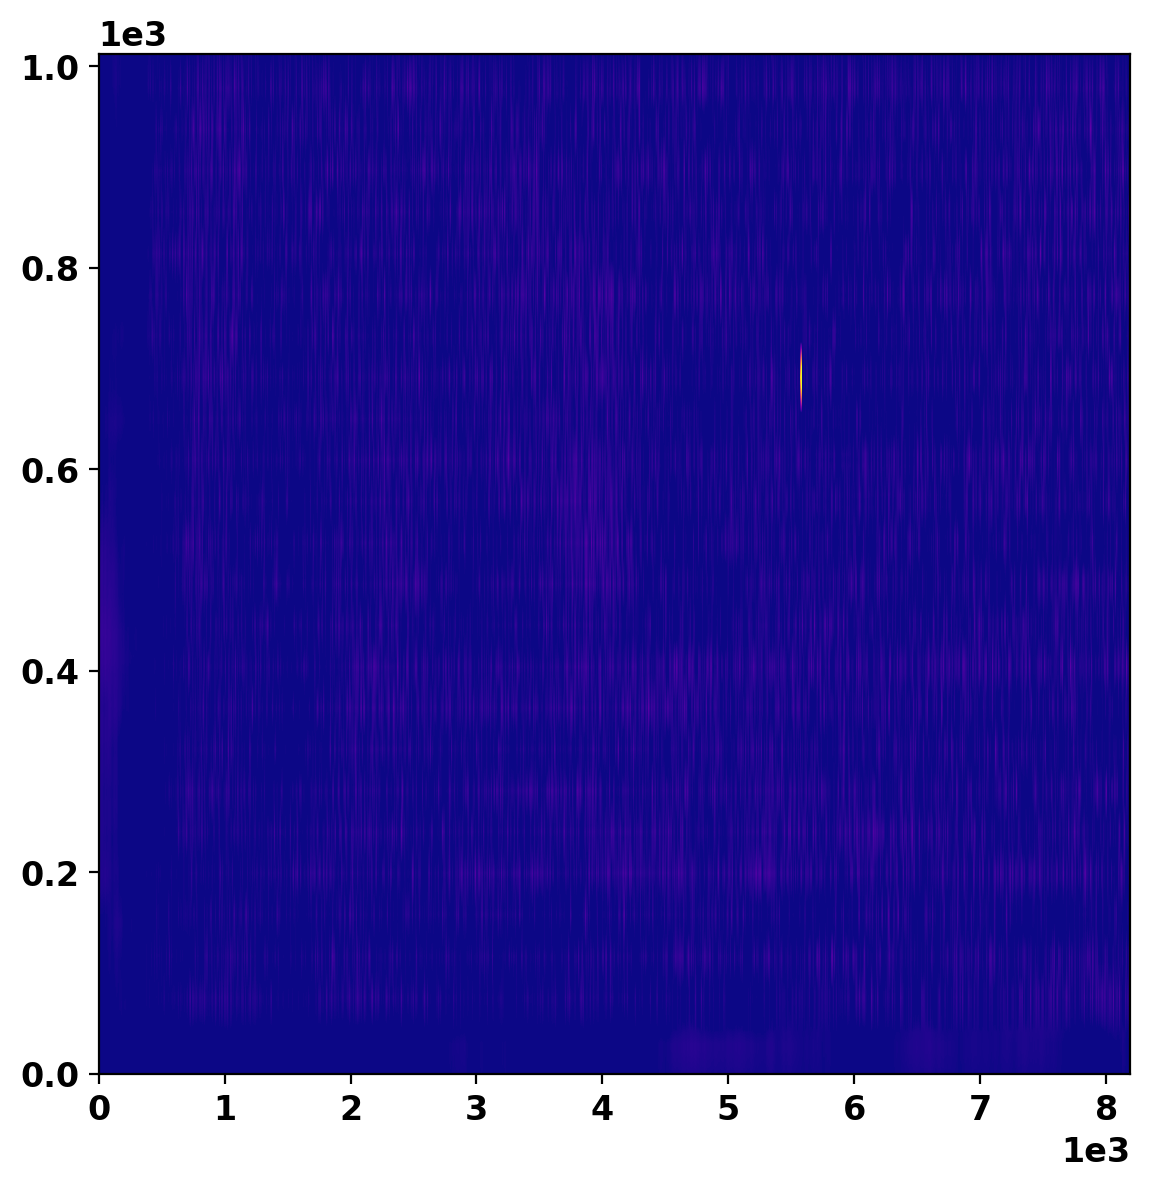

In [34]:
# sky image
fluence = 100
sky = decode(wfm, detector) * fluence

sky_ = np.pow(np.clip(sky, a_min=1e-5, a_max=None), 0.85)

fig, ax = dsp.config_subplots(ptype='image')
ax.imshow(sky_, cmap='hot', origin='lower', aspect=ASPECT, vmin=0)
# fig.savefig(f'{save_to}/sky_image.png')
plt.show()


# sky significance
from var import sky_variance, sky_significance

n, m  = wfm.shape_sky

variance = sky_variance(wfm, detector)
snr = sky_significance(sky, variance, ycut=int(1e-2 * n), xcut=int(1e-2 * m))

snr_ = np.pow(np.clip(snr, a_min=1e-5, a_max=None), 0.95)

fig, ax = dsp.config_subplots(ptype='image')
ax.imshow(snr_, cmap='plasma', origin='lower', aspect=ASPECT, vmin=0, vmax=50)
fig.savefig(f'{save_to}/skysnr_image.png')
plt.show()